# Simple Linear Regression — Experience vs Salary (Pakistan IT Industry)

**Dataset:** Data of IT professionals in Pakistan with two columns: `experience_years` (number of years of work experience) and `salary_thousand_pkr` (salary in thousands of Pakistani Rupees).

**Description:** Simple Linear Regression uses **one input feature** (X) to predict **one output** (Y). In this dataset, the relationship is **simple and linear**. As the years of experience increase, the salary also increases at a steady rate.

**Formula:** `salary = intercept + slope * experience_years`


## 1. Libraries aur Dataset Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

df = pd.read_csv('pakistan_it_experience_salary.csv')
df.head()

,experience_years,salary_thousand_pkr
0,8.3,120.8
1,14.4,178.4
2,0.0,45.3
3,6.0,111.3
4,2.9,66.6


In [2]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   experience_years     300 non-null    float64
 1   salary_thousand_pkr  300 non-null    float64
dtypes: float64(2)
memory usage: 4.8 KB


,experience_years,salary_thousand_pkr
count,300.000000,300.000000
mean,10.170333,136.908667
std,5.975123,56.864298
min,0.000000,30.000000
25%,4.975000,89.175000
50%,10.950000,143.050000
75%,15.100000,186.075000
max,19.900000,234.800000


## 2. Data Visualization (Before Training)

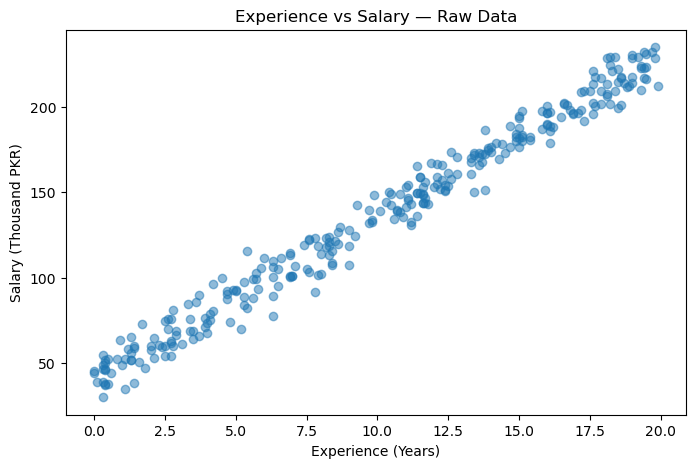

In [3]:
plt.figure(figsize=(8,5))
plt.scatter(df['experience_years'], df['salary_thousand_pkr'], alpha=0.5)
plt.xlabel('Experience (Years)')
plt.ylabel('Salary (Thousand PKR)')
plt.title('Experience vs Salary — Raw Data')
plt.show()

## 3. Train-Test Split aur Model Training

In [4]:
X = df[['experience_years']]
y = df['salary_thousand_pkr']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Intercept : {model.intercept_:.2f}")
print(f"Slope     : {model.coef_[0]:.2f}")
print(f"Equation  : salary = {model.intercept_:.2f} + ({model.coef_[0]:.2f} * experience_years)")

Intercept : 40.88
Slope     : 9.47
Equation  : salary = 40.88 + (9.47 * experience_years)


## 4. Model Evaluation

In [5]:
preds = model.predict(X_test)

print(f"R2 Score : {r2_score(y_test, preds):.4f}")
print(f"MAE      : {mean_absolute_error(y_test, preds):.2f} thousand PKR")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test, preds)):.2f} thousand PKR")

R2 Score : 0.9806
MAE      : 6.39 thousand PKR
RMSE     : 7.58 thousand PKR


## 5. Visualization — Fitted Regression Line

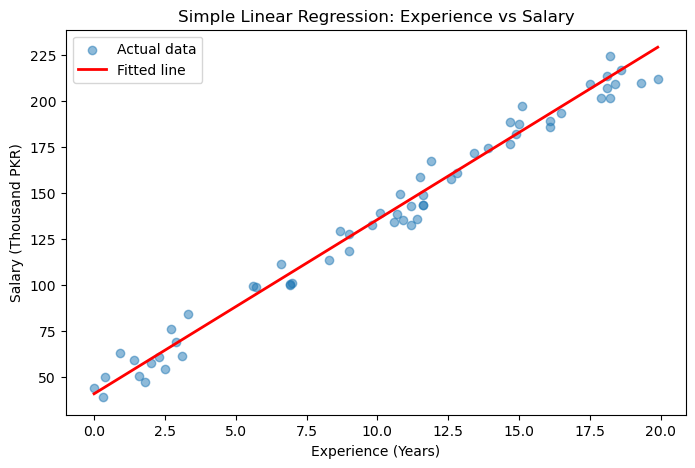

In [6]:
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, alpha=0.5, label='Actual data')
order = np.argsort(X_test['experience_years'].values)
plt.plot(X_test['experience_years'].values[order], preds[order], color='red', linewidth=2, label='Fitted line')
plt.xlabel('Experience (Years)')
plt.ylabel('Salary (Thousand PKR)')
plt.title('Simple Linear Regression: Experience vs Salary')
plt.legend()
plt.show()

## 6. New Value Prediction

Now we use the trained model to predict the salary for new experience values. The model takes the new **experience_years** as input and estimates the **salary_thousand_pkr** based on the learned linear relationship.


In [7]:
new_exp = pd.DataFrame({'experience_years': [3]})
pred_salary = model.predict(new_exp)
print(f"3 saal experience wale ki predicted salary: {pred_salary[0]:.2f} thousand PKR")

print()
for exp in [0, 2, 5, 10, 15, 20]:
    p = model.predict(pd.DataFrame({'experience_years':[exp]}))[0]
    print(f"Experience = {exp:>2} years  ->  Predicted Salary = {p:.2f} thousand PKR")

3 saal experience wale ki predicted salary: 69.27 thousand PKR

Experience =  0 years  ->  Predicted Salary = 40.88 thousand PKR
Experience =  2 years  ->  Predicted Salary = 59.81 thousand PKR
Experience =  5 years  ->  Predicted Salary = 88.21 thousand PKR
Experience = 10 years  ->  Predicted Salary = 135.54 thousand PKR
Experience = 15 years  ->  Predicted Salary = 182.87 thousand PKR
Experience = 20 years  ->  Predicted Salary = 230.20 thousand PKR


## 7. Summary

* Simple Linear Regression learned the **straight-line relationship** between **experience** and **salary**.
* A **high R² score** shows that **experience** alone explains most of the changes in **salary**, because this dataset was created with a **clear linear relationship**.
* In real-world situations, salary also depends on other factors such as **skills, education, company, job role, and city**. In those cases, **Multiple Linear Regression** is a better choice because it uses more than one input feature.
